# Proyek Analisis Data: Bike Sharing
- **Nama:** Abel Gilang Saputra
- **Email:** torgelmach123@gmail.com
- **ID Dicoding:** cdcc014d6y1439

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan rata-rata penyewaan sepeda harian antar musim secara spesifik sepanjang tahun 2012?
- **Pertanyaan 2:** Pada jam berapa volume penyewaan sepeda mencapai titik puncaknya pada hari kerja selama kuartal terakhir (Oktober - Desember) tahun 2012?
- **Pertanyaan 3:** Bagaimana pengaruh kondisi cuaca terhadap total penyewaan sepeda khusus pada akhir pekan selama musim panas tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [12]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset `day.csv` memuat data penyewaan agregasi harian, sedangkan `hour.csv` memuat data agregasi per jam.


### Assessing Data

#### Identifying ... problem

In [13]:
print("Info day_df:\n", day_df.info())
print("\nInfo hour_df:\n", hour_df.info())

print("\nMissing values day_df:\n", day_df.isna().sum().sum())
print("Duplicated day_df:\n", day_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
Info day_df:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 1737

**Steps to Take:**
- Format tanggal belum diubah ke datetime, kita akan ubah itu
- Untuk beberapa kolom data kategorical yang masih menjadi numerik, harus diubah kembali ke tipe data object agar mudah dibaca saat visualisasi (pada kasus ini adalah kolom season dan weathersit)

**Insight:** (Opsional)
- Tidak ditemukan *missing value* maupun data duplikat pada kedua dataset. Fokus pembersihan hanya pada penyesuaian tipe data dan label kategori.

### Cleaning Data

#### Fixing ... problem

In [14]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_map = {1: "Clear", 2: "Mist", 3: "Light Snow/Rain", 4: "Heavy Rain"}

for df in [day_df, hour_df]:
    df["season_label"] = df["season"].map(season_map)
    df["weather_label"] = df["weathersit"].map(weather_map)

print("Kolom Smenatara day_df : \n")
display(day_df.head(10))
print("Kolom Smenatara hour_df : \n")
display(hour_df.head(10))

Kolom Smenatara day_df : 



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Mist
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Spring,Clear
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Spring,Clear
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606,Spring,Clear
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510,Spring,Mist
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959,Spring,Mist
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822,Spring,Clear
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321,Spring,Clear


Kolom Smenatara hour_df : 



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,Spring,Clear
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,Spring,Clear
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,Spring,Clear
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,Spring,Clear
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,Spring,Clear
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1,Spring,Mist
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2,Spring,Clear
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3,Spring,Clear
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8,Spring,Clear
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14,Spring,Clear


**Insight:** (Opsional)
- Kolom tanggal sudah benar formatnya (`datetime`)
- Kolom kolom kategorical (season dan weathersit) sudah kembali benar, menjadi string yang mudah dibaca dan divisualisasi

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
day_2012 = day_df[day_df["yr"] == 1]
season_avg_2012 = day_2012.groupby("season_label")["cnt"].mean().reset_index().sort_values(by="cnt", ascending=False)
display(season_avg_2012)

hour_q4_2012 = hour_df[(hour_df["yr"] == 1) & (hour_df["mnth"].isin([10, 11, 12])) & (hour_df["workingday"] == 1)]
hourly_q4_trend = hour_q4_2012.groupby("hr")["cnt"].mean().reset_index()
display(hourly_q4_trend.head())

summer_weekend_2012 = day_df[(day_df["yr"] == 1) & (day_df["season_label"] == "Summer") & (day_df["workingday"] == 0)]
weather_summer_impact = summer_weekend_2012.groupby("weather_label")["cnt"].sum().reset_index()
display(weather_summer_impact)

,season_label,cnt
0,Fall,6824.244681
2,Summer,6209.489130
3,Winter,5791.865169
1,Spring,3531.296703


,hr,cnt
0,0,41.852459
1,1,17.900000
2,2,9.000000
3,3,5.086207
4,4,7.389831


,weather_label,cnt
0,Clear,138593
1,Light Snow/Rain,1027
2,Mist,38106


**Insight:** (Opsional)
- Filter bertingkat telah diterapkan sesuai batasan waktu (tahun 2012, kuartal 4, dan akhir pekan musim panas) untuk mendapatkan gambaran tren spesifik.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1639/236835061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="season_label", y="cnt", data=season_avg_2012, palette="viridis")


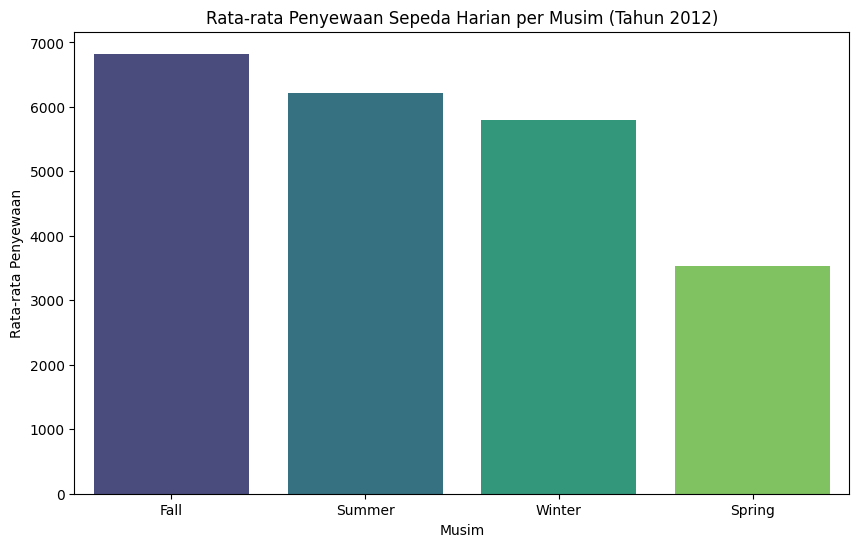

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x="season_label", y="cnt", data=season_avg_2012, palette="viridis")
plt.title("Rata-rata Penyewaan Sepeda Harian per Musim (Tahun 2012)")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### Pertanyaan 2:

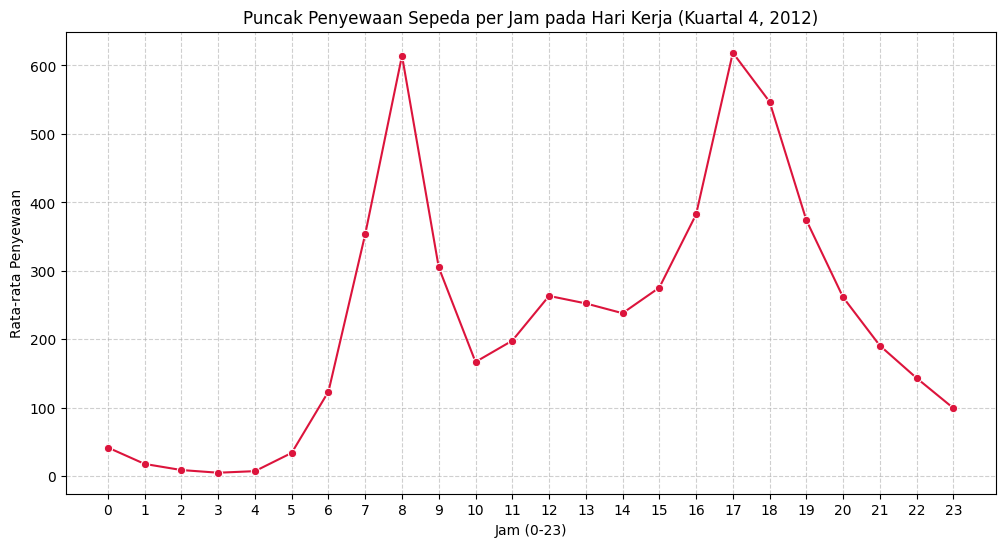

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="hr", y="cnt", data=hourly_q4_trend, marker="o", color="crimson")
plt.title("Puncak Penyewaan Sepeda per Jam pada Hari Kerja (Kuartal 4, 2012)")
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Pertanyaan 3:

/tmp/ipykernel_1639/3569909584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weather_label", y="cnt", data=weather_summer_impact, palette="mako")


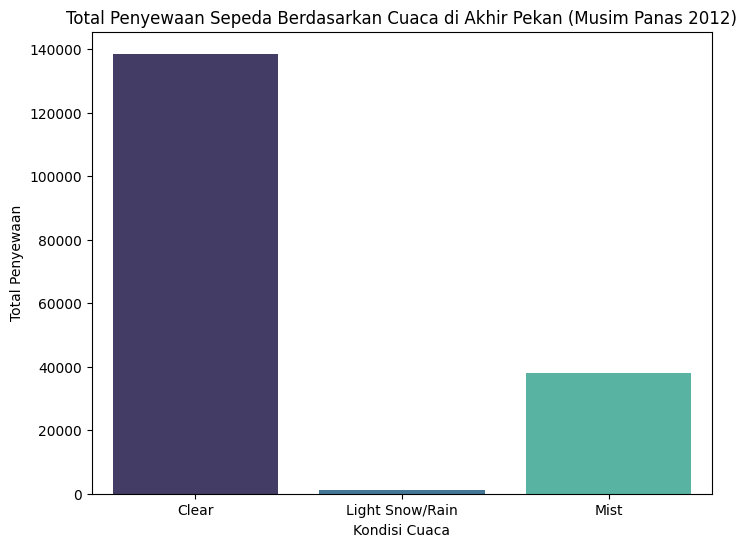

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(x="weather_label", y="cnt", data=weather_summer_impact, palette="mako")
plt.title("Total Penyewaan Sepeda Berdasarkan Cuaca di Akhir Pekan (Musim Panas 2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Total Penyewaan")
plt.show()

**Insight:** (Opsional)
- **Visualisasi 1:** Menunjukkan dominasi musim Fall secara jelas.
- **Visualisasi 2:** *Line chart* dengan tegas memperlihatkan dua titik puncak di jam masuk dan pulang kantor.
- **Visualisasi 3:** Mengkonfirmasi bahwa cuaca cerah mutlak diperlukan untuk penyewaan akhir pekan di musim panas.

## Analisis Lanjutan (Opsional)

Manual Clustering (Binning)
Untuk mendapatkan *insight* perilaku penyewa secara lebih makro, kita akan menerapkan teknik *clustering* tanpa *machine learning* menggunakan metode **Binning**. Data jam operasional (0-23) akan dikelompokkan ke dalam 4 klaster waktu utama:
1. **Dini Hari:** 00:00 - 05:00
2. **Pagi:** 06:00 - 11:00
3. **Siang:** 12:00 - 17:00
4. **Malam:** 18:00 - 23:00

/tmp/ipykernel_1639/1789869923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_analysis = hour_df.groupby('time_cluster')['cnt'].mean().reset_index()


,time_cluster,cnt
2,Siang,295.483886
3,Malam,225.757555
1,Pagi,208.100688
0,Dini Hari,24.908559


/tmp/ipykernel_1639/1789869923.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time_cluster', y='cnt', data=cluster_analysis, palette='crest')


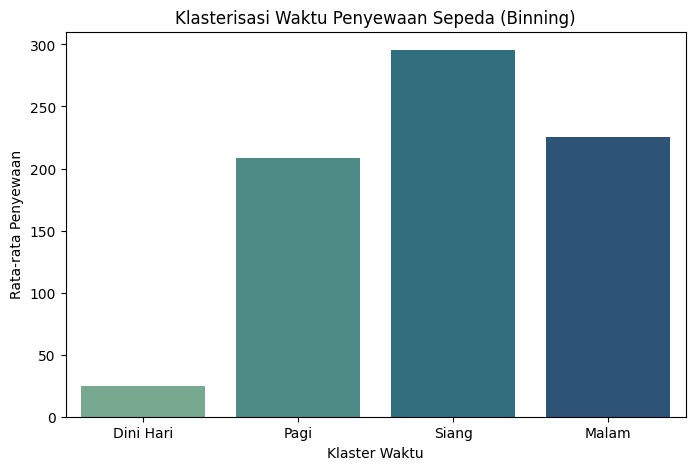

In [19]:
bins = [-1, 5, 11, 17, 23]
labels = ['Dini Hari', 'Pagi', 'Siang', 'Malam']

hour_df['time_cluster'] = pd.cut(hour_df['hr'], bins=bins, labels=labels)

cluster_analysis = hour_df.groupby('time_cluster')['cnt'].mean().reset_index()
cluster_analysis = cluster_analysis.sort_values(by='cnt', ascending=False)
display(cluster_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(x='time_cluster', y='cnt', data=cluster_analysis, palette='crest')
plt.title('Klasterisasi Waktu Penyewaan Sepeda (Binning)')
plt.xlabel('Klaster Waktu')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Sepanjang tahun 2012, musim gugur (Fall) mencatat rata-rata penyewaan harian tertinggi, sedangkan musim semi (Spring) menjadi musim dengan rata-rata paling sepi.
- **Conclusion pertanyaan 2:** Selama Kuartal 4 tahun 2012, penyewaan pada hari kerja secara konsisten memuncak di pukul 08:00 (berangkat aktivitas) dan pukul 17:00 (pulang aktivitas). Kemungkinan ini disebabkan karena traffic pergi dan pulang kerja.
- **Conclusion pertanyaan 3:** Pada akhir pekan selama musim panas 2012, cuaca cerah (Clear) menyumbang total penyewaan tertinggi, sementara cuaca buruk menekan angka penyewaan dengan drastis.

**Rekomendasi Action Item:**
- **Alokasi Armada Q4:** Fokuskan distribusi dan ketersediaan armada sepeda di area perkantoran dan stasiun transit menjelang pukul 08:00 dan 17:00 pada hari kerja.
- **Strategi Akhir Pekan:** Terapkan promo khusus pengguna *casual* saat cuaca mulai memburuk atau berkabut di akhir pekan musim panas guna menstimulasi angka penyewaan.
- **Maintenance Optimal:** Manfaatkan periode sepi di musim semi (Spring) untuk melakukan pemeliharaan besar-besaran agar seluruh armada siap menghadapi puncak permintaan di musim gugur (Fall).